# CCR Sensitivity across Profiled Hull–White Parameter Scenarios

This notebook propagates selected fixed-mean-reversion scenarios through a stylised 10Y par OIS. Volatility is re-optimised for each scenario using the frozen five-instrument basket.

The resulting exposure and CVA differences are **illustrative within-model sensitivity**, not a statistical uncertainty interval or a comparison of equally acceptable market fits. Calibration quality worsens across the selected scenarios, and no bid/ask-based acceptance rule has been established.

CVA uses expected path-discounted exposure under the money-market risk-neutral measure, with independent constant-hazard default. Ordinary EE/PFE are reported separately.

## 1. Market inputs and reference trade

The frozen 2 September 2026 SOFR curve is reused. The reference trade is a 10Y pay-fixed OIS starting today, $T_0=0$, with notional $\mathcal{N}=10$ million and coupon $K=S_{0,n}(0)$. Its initial value is approximately zero.

The credit model uses constant hazard $\gamma=0.02$ and recovery $\mathrm{REC}=0.40$, independent of market factors. Exposure is reported monthly, with a weekly simulation grid integrating floating accrual and discounting.

In [1]:
import numpy as np
import pandas as pd

from pathlib import Path

from ccr_validation.curves import DiscountCurve
from ccr_validation.swaps import InterestRateSwap
from ccr_validation.hull_white import HullWhite1F
from ccr_validation.exposure import exposure_profile
from ccr_validation.cva import ConstantHazardCreditModel, unilateral_cva
from ccr_validation.calibration import (
    fit_sigma_for_fixed_a, price_calibration_row, hw_implied_black_vol,
)

import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator

plt.style.use("bmh")

plt.rcParams.update({
    "figure.figsize": (9, 5),
    "font.family": "serif",
    "font.serif": ["Computer Modern"],
    "text.usetex": True,
    "font.size": 12,
    "axes.titlesize": 12,
    "axes.labelsize": 12,
})

In [2]:
# Frozen SOFR curve.
curve_path = Path(
    "../data/processed/sofr_ois_pchip_curve_2026-09-02.csv"
)

curve_nodes = pd.read_csv(curve_path)

curve = DiscountCurve(
    times=curve_nodes["time"].to_numpy(),
    discount_factors=curve_nodes["discount_factor"].to_numpy(),
)

# Reference 10Y pay-fixed par swap.
notional = 10_000_000
maturity = 10.0
payments_per_year = 1

par_swap = InterestRateSwap(
    notional=notional,
    fixed_rate=0.0,
    maturity=maturity,
    payments_per_year=payments_per_year,
    pay_fixed=True,
)

par_rate = par_swap.par_rate(curve)

swap = InterestRateSwap(
    notional=notional,
    fixed_rate=par_rate,
    maturity=maturity,
    payments_per_year=payments_per_year,
    pay_fixed=True,
)

# Simplified unilateral credit assumptions.
credit = ConstantHazardCreditModel(
    hazard_rate=0.02,
    recovery_rate=0.40,
)

# Baseline exposure / simulation settings.
exposure_dt = 1.0 / 12.0
simulation_dt = 1.0 / 52.0
n_paths = 50_000
seed = 42

print(f"10Y par rate: {100 * par_rate:.4f}%")
print(f"Initial swap PV: {swap.pv(curve):,.6f}")


10Y par rate: 4.4753%
Initial swap PV: 0.000000


The par rate is approximately 4.48%, and the initial swap PV is numerically zero. This ensures that differences in future exposure are driven by the model dynamics rather than by starting from an off-market trade.

## 2. Profiled Hull–White parameter scenarios

The source-linked calibration basket is reused without changing its instrument economics. The illustrative mean-reversion values are

$$a\in\{0.001,0.01,0.02,0.03\}.$$

For each fixed $a$, $\sigma_{\mathrm{HW}}$ is re-optimised using Black implied-volatility residuals. The low-$a$ reference is a practical scenario rather than a precisely estimated production parameter. RMS multipliers describe fit deterioration; they are not confidence bounds or market-fit acceptance criteria.

In [3]:
market_date = pd.Timestamp("2026-09-02")

calibration_basket = pd.read_csv(
    "../results/hw_swaption_calibration_basket_2026-09-02.csv",
    parse_dates=[
        "First exercise date",
        "Maturity date of the underlier",
    ],
)

calibration_basket[
    [
        "option_expiry_years",
        "underlying_tenor_years",
        "strike",
        "forward_rate",
        "market_black_vol",
    ]
]


,option_expiry_years,underlying_tenor_years,strike,forward_rate,market_black_vol
0,0.063014,7.016438,0.043375,0.043340,0.184321
1,0.082192,10.019178,0.044275,0.044236,0.169631
2,1.000000,30.035616,0.045980,0.045971,0.173572
3,2.010959,20.019178,0.046870,0.046949,0.182934
4,3.008219,10.010959,0.046200,0.046087,0.208665


In [4]:
a_values = [
    0.001,
    0.01,
    0.02,
    0.03,
]

rows = []

for a in a_values:
    sigma, rms = fit_sigma_for_fixed_a(
        a=a,
        curve=curve,
        calibration_basket=calibration_basket,
        market_date=market_date,
        initial_sigma=0.008,
        sigma_bounds=(1e-5, 0.2),
    )

    rows.append({
        "a": a,
        "sigma": sigma,
        "rms_vol_error": rms,
    })

parameter_sets = pd.DataFrame(rows)

J_reference = parameter_sets.loc[parameter_sets["a"] == 0.001, "rms_vol_error"].iloc[0]

parameter_sets["relative_objective"] = parameter_sets["rms_vol_error"] / J_reference

parameter_sets


,a,sigma,rms_vol_error,relative_objective
0,0.001,0.008152,0.016085,1.000000
1,0.010,0.008659,0.017547,1.090829
2,0.020,0.009217,0.020415,1.269164
3,0.030,0.009770,0.023845,1.482390


As $a$ increases, the fitted $\sigma_{\mathrm{HW}}$ increases while calibration RMS worsens. The endpoint RMS values are approximately 1.61 and 2.38 volatility percentage points, a roughly 48% increase in RMS (about 120% in squared error). The per-instrument residual table below makes this trade-off visible.

No bid/ask or transaction-price uncertainty allowance has been established. Consequently, the scenarios are not described as equally acceptable calibrations.

In [5]:
residual_rows = []

for _, parameters in parameter_sets.iterrows():

    fitted_model = HullWhite1F(
        curve=curve, 
        a=parameters["a"], 
        sigma=parameters["sigma"],
    )

    for _, instrument in calibration_basket.iterrows():

        model_price = price_calibration_row(
            row=instrument, 
            model=fitted_model, 
            market_date=market_date,
        )

        model_vol = hw_implied_black_vol(
            row=instrument, 
            model=fitted_model, 
            market_date=market_date,
            )

        residual_rows.append({
            "a": parameters["a"],
            "source_dissemination_identifier": instrument["Dissemination Identifier"],
            "option_expiry_years": instrument["option_expiry_years"],
            "underlying_tenor_years": instrument["underlying_tenor_years"],
            "market_premium": instrument["premium_per_notional"],
            "model_premium": model_price,
            "premium_error_pct": 100 * (model_price / instrument["premium_per_notional"] - 1),
            "black_vol_error_pp": 100 * (model_vol - instrument["market_black_vol"]),
        })

parameter_fit_residuals = pd.DataFrame(residual_rows)

parameter_fit_residuals

,a,source_dissemination_identifier,option_expiry_years,underlying_tenor_years,market_premium,model_premium,premium_error_pct,black_vol_error_pp
0,0.001,5095740835000000101,0.063014,7.016438,0.00470,0.004917,4.621487,0.833578
1,0.001,5095585424000000301,0.082192,10.019178,0.00675,0.007502,11.140341,1.847401
2,0.001,5095941783000000101,1.000000,30.035616,0.04930,0.051285,4.027084,0.699849
3,0.001,5093454675000000101,2.010959,20.019178,0.05825,0.056012,-3.842467,-0.712450
4,0.001,5091707032000000101,3.008219,10.010959,0.04630,0.040092,-13.407779,-2.798574
5,0.010,5095740835000000101,0.063014,7.016438,0.00470,0.005071,7.896405,1.424282
6,0.010,5095585424000000301,0.082192,10.019178,0.00675,0.007645,13.261874,2.199223
7,0.010,5095941783000000101,1.000000,30.035616,0.04930,0.048984,-0.640137,-0.111227
8,0.010,5093454675000000101,2.010959,20.019178,0.05825,0.054740,-6.024933,-1.116910
9,0.010,5091707032000000101,3.008219,10.010959,0.04630,0.040320,-12.915915,-2.696106


## 3. Effect on future rate dynamics

With $x_0=0$, the Hull–White state variance is

$$
\operatorname{Var}^{\mathbb Q}(x_t)
=\frac{\sigma_{\mathrm{HW}}^2}{2a}(1-e^{-2at}).
$$

For small $at$, this approaches $\sigma_{\mathrm{HW}}^2t$. Larger $a$ strengthens mean reversion, while the profiled $\sigma_{\mathrm{HW}}$ also increases. The plot compares their combined effect on state uncertainty; simulation uses the exact transition validated in Notebook 04.

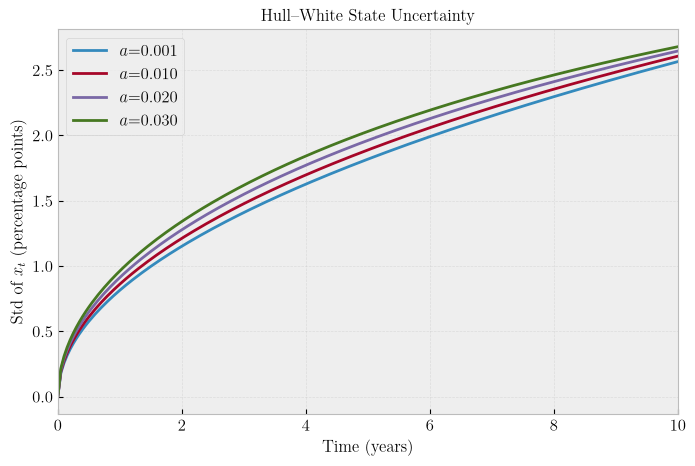

In [6]:
times = np.linspace(0.0, maturity, 201)

plt.figure(figsize=(8, 5))

for _, row in parameter_sets.iterrows():
    a = row["a"]
    sigma = row["sigma"]

    variance = sigma**2 / (2.0 * a) * (1.0 - np.exp(-2.0 * a * times))

    plt.plot(
        times,
        100 * np.sqrt(variance),
        label=f"$a$={a:.3f}",
    )

plt.xlim(0, 10)
plt.xlabel("Time (years)")
plt.ylabel("Std of $x_t$ (percentage points)")
plt.title("Hull–White State Uncertainty")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


Over the 10Y horizon, the increase in fitted $\sigma_{\mathrm{HW}}$ dominates the additional mean-reversion damping: state uncertainty is slightly larger for the larger-$a$ calibrations. The curves remain close because the fitted-volatility adjustment partly offsets changes in mean reversion.

Mean reversion also changes the **persistence** of shocks. Conditional state deviations decay exactly over an interval $\Delta t$: $\mathbb E^{\mathbb Q}[x_{t+\Delta t}\mid\mathcal F_t]=e^{-a\Delta t}x_t$.

In [7]:
horizons = [
    ("1Y", 1.0),
    ("5Y", 5.0),
    ("10Y", 10.0),
]

rows = []

for _, row in parameter_sets.iterrows():
    a = row["a"]

    result = {"a": a}

    result.update({
        label: np.exp(-a * horizon) for label, horizon in horizons
    })

    rows.append(result)

persistence = pd.DataFrame(rows)
persistence

,a,1Y,5Y,10Y
0,0.001,0.999000,0.995012,0.990050
1,0.010,0.990050,0.951229,0.904837
2,0.020,0.980199,0.904837,0.818731
3,0.030,0.970446,0.860708,0.740818


The marginal state-volatility differences are modest, but the persistence structure differs more materially at long horizons. This is the channel through which weak identification of $a$ can affect the distribution of future swap values even when current swaption prices are similar.

## 4. Propagation to EE and PFE

Each parameter set is propagated through the reference swap using $N=50{,}000$ paths. For any interval $s\le t$, discounting and floating accumulation are inverses:

$$
D(s,t)=\exp\left(-\int_s^t r_u\,du\right),\qquad
G(s,t)=\exp\left(\int_s^t r_u\,du\right)=D(s,t)^{-1}.
$$

Between payments, $T_k\le t<T_{k+1}$, the payer swap value is

$$
V_t=\mathcal{N}[G(T_k,t)-P(t,T_n)-K A_{k,n}(t)],
\qquad
A_{k,n}(t)=\sum_{i=k+1}^{n}\alpha_iP(t,T_i).
$$

Here the annual accrual fractions are $\alpha_i=1$. Accumulation starts at the last reset, so $G(T_k,T_k)=1$; after the final payment, $V_{T_n}=0$.

Positive exposure is $E_t^{(j)}=(V_t^{(j)})^+$. Its risk-neutral mean and quantile are

$$
\operatorname{EE}^{\mathbb Q}(t)\approx\frac{1}{N}\sum_{j=1}^{N}E_t^{(j)},
\qquad
\operatorname{PFE}^{\mathbb Q}_q(t)=\operatorname{Quantile}^{\mathbb Q}_q(E_t).
$$

Common random numbers across parameter sets reduce sampling noise in the comparison.

In [8]:
profiles = {}

for _, row in parameter_sets.iterrows():
    a = row["a"]
    sigma = row["sigma"]

    model = HullWhite1F(
        curve=curve,
        a=a,
        sigma=sigma,
    )

    profiles[a] = exposure_profile(
        swap=swap,
        model=model,
        n_paths=n_paths,
        pfe_quantiles=(0.95, 0.99),
        seed=seed,
        simulation_method="exact",
        exposure_dt=exposure_dt,
        simulation_dt=simulation_dt,
    )


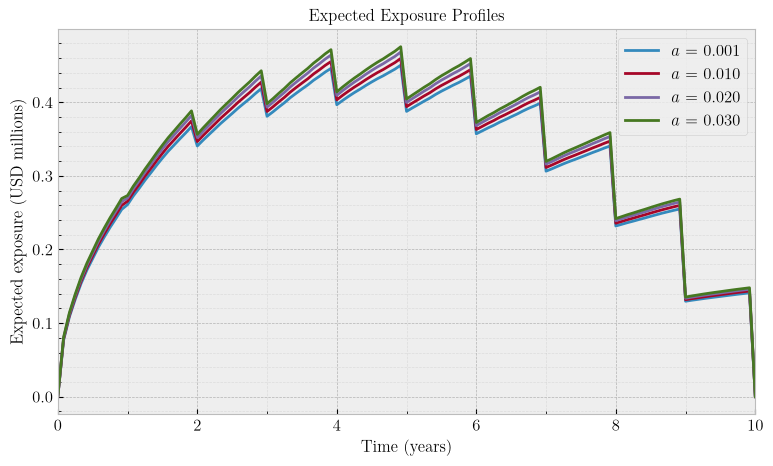

In [9]:
fig, ax = plt.subplots(figsize=(9, 5))

for a, profile in profiles.items():
    ax.plot(
        profile["times"],
        profile["ee"] / 1e6,
        label=fr"$a$ = {a:.3f}",
    )

ax.set_xlim(0, 10)
ax.set_title("Expected Exposure Profiles")
ax.set_xlabel("Time (years)")
ax.set_ylabel("Expected exposure (USD millions)")

ax.legend()

ax.xaxis.set_minor_locator(AutoMinorLocator(2))
ax.yaxis.set_minor_locator(AutoMinorLocator())

ax.grid(True, which="major")
ax.grid(True, which="minor", alpha=0.3)

figures_path = Path("../results/figures")
figures_path.mkdir(parents=True, exist_ok=True)

expected_exposure_path = figures_path / "expected_exposure_profiles.png"

fig.savefig(
    expected_exposure_path,
    dpi=200,
    bbox_inches="tight",
)

plt.show()

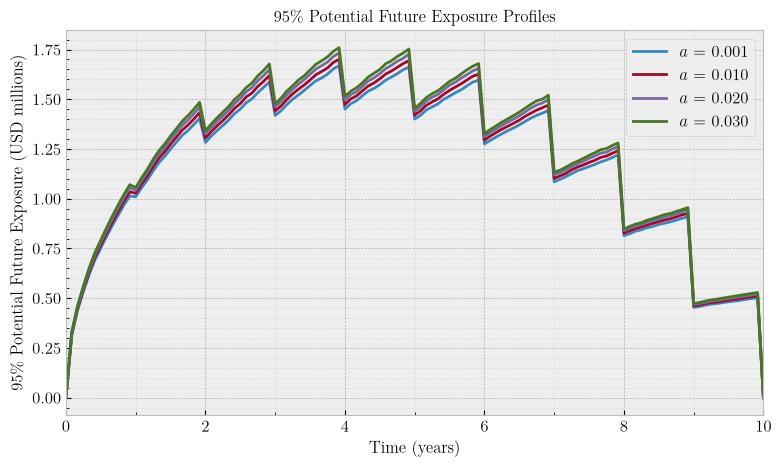

In [10]:
fig, ax = plt.subplots()

for a, profile in profiles.items():
    ax.plot(
        profile["times"],
        profile["pfe_95"] / 1e6,
        label=fr"$a$ = {a:.3f}",
    )

ax.set_xlim(0, 10)
ax.set_title(r"95\% Potential Future Exposure Profiles")
ax.set_xlabel("Time (years)")
ax.set_ylabel(r"95\% Potential Future Exposure (USD millions)")

ax.legend()

ax.xaxis.set_minor_locator(AutoMinorLocator(2))
ax.yaxis.set_minor_locator(AutoMinorLocator())

ax.grid(True, which="major")
ax.grid(True, which="minor", alpha=0.3)

plt.show()

The exposure profiles have the expected hump shape: uncertainty initially grows, while the remaining maturity and outstanding cashflows shrink as the trade approaches maturity. The sawtooth pattern is generated by annual OIS payment dates: realised floating accrual builds between payments and resets immediately after each payment.

Across the parameter sets, EE and PFE increase monotonically with $a$ because the associated increase in fitted $\sigma_{\mathrm{HW}}$ dominates the stronger mean reversion over this horizon.

In [11]:
rows = []

for a, profile in profiles.items():
    rows.append({
        "a": a,
        "max_ee": np.max(profile["ee"]),
        "max_pfe_95": np.max(profile["pfe_95"]),
        "max_pfe_99": np.max(profile["pfe_99"]),
    })

exposure_summary = pd.DataFrame(rows)

reference = exposure_summary.loc[
    exposure_summary["a"] == 0.001
].iloc[0]

for metric in ["max_ee", "max_pfe_95", "max_pfe_99"]:
    exposure_summary[f"{metric}_change_pct"] = (
        100
        * (
            exposure_summary[metric]
            / reference[metric]
            - 1.0
        )
    )

exposure_summary


,a,max_ee,max_pfe_95,max_pfe_99,max_ee_change_pct,max_pfe_95_change_pct,max_pfe_99_change_pct
0,0.001,450394.059177,1.669055e+06,2.262401e+06,0.000000,0.000000,0.000000
1,0.010,459562.127169,1.701735e+06,2.305824e+06,2.035566,1.957994,1.919325
2,0.020,468229.855110,1.733685e+06,2.345850e+06,3.960042,3.872246,3.688499
3,0.030,475480.171684,1.759128e+06,2.382022e+06,5.569814,5.396678,5.287359


Relative to $a=0.001$, the $a=0.03$ calibration increases peak EE by approximately **5.6%**, 95% PFE by **5.4%**, and 99% PFE by **5.3%**. The effect is therefore systematic across both expected and tail exposure measures, but remains moderate for this representative 10Y par swap.

## 5. Propagation to unilateral CVA

Each exposure is multiplied by its own path discount factor before averaging:

$$
\operatorname{DEE}^{\mathbb Q}(t)
=\mathbb E^{\mathbb Q}[D(0,t)E_t]
\approx\frac{1}{N}\sum_{j=1}^{N}D^{(j)}(0,t)E_t^{(j)}.
$$

The survival function is $Q(t)=\mathbb Q(\tau_C>t)=e^{-\gamma t}$, where $\tau_C$ is counterparty default time. With independent default and $\mathrm{LGD}=1-\mathrm{REC}$,

$$
\mathrm{CVA}_0\approx\mathrm{LGD}\sum_{k=1}^{m}
\operatorname{DEE}^{\mathbb Q}(u_k)[Q(u_{k-1})-Q(u_k)].
$$

The $u_k$ are exposure dates and each survival difference is the default probability for that interval. Floating accumulation uses $G(T_k,t)$ from the last reset; CVA discounting uses $D(0,t)$ from today throughout the trade.

The discount integral is approximated on the full simulation grid. Its error is separate from the default-time quadrature tested below. Discounting and exposure remain dependent, so today's curve is not applied to ordinary EE as an additional discount factor.

In [12]:
rows = []

for a, profile in profiles.items():
    cva = unilateral_cva(
        times=profile["times"],
        discounted_ee=profile["discounted_ee"],
        credit_model=credit,
    )

    rows.append({
        "a": a,
        "cva": cva,
    })

cva_summary = pd.DataFrame(rows)

cva_reference = cva_summary.loc[cva_summary["a"] == 0.001, "cva"].iloc[0]

cva_summary["cva_change_pct"] = 100 * (cva_summary["cva"] / cva_reference - 1.0)

cva_summary


,a,cva,cva_change_pct
0,0.001,27378.964194,0.000000
1,0.010,27851.490420,1.725873
2,0.020,28287.056062,3.316750
3,0.030,28640.515043,4.607738


The path-discounted baseline CVA increases from **$27.38k to $28.64k**, or **4.6077%**, across the selected endpoints. The higher-$a$ scenario has materially worse calibration fit. This is an illustrative parameter sensitivity, not a confidence interval or production model-risk bound.

## 6. Monte Carlo robustness

The endpoint cases are rerun across five paired seeds with 50,000 paths each. This checks simulation noise in the relative comparison; it does not quantify market-data uncertainty or parameter confidence.

In [13]:
seeds = [
    11,
    22,
    33,
    44,
    55,
]

endpoint_sets = parameter_sets[parameter_sets["a"].isin([0.001, 0.03])]

rows = []

for seed_i in seeds:
    for _, row in endpoint_sets.iterrows():
        a = row["a"]

        model = HullWhite1F(
            curve=curve,
            a=a,
            sigma=row["sigma"],
        )

        profile = exposure_profile(
            swap=swap,
            model=model,
            n_paths=n_paths,
            pfe_quantiles=(0.95, 0.99),
            seed=seed_i,
            simulation_method="exact",
            exposure_dt=exposure_dt,
            simulation_dt=simulation_dt,
        )

        cva = unilateral_cva(
            times=profile["times"],
            discounted_ee=profile["discounted_ee"],
            credit_model=credit,
        )

        rows.append({
            "seed": seed_i,
            "a": a,
            "cva": cva,
        })

mc_results = pd.DataFrame(rows)

mc_pivot = mc_results.pivot(
    index="seed",
    columns="a",
    values="cva",
)

mc_pivot["change_pct"] = 100 * (mc_pivot[0.03] / mc_pivot[0.001] - 1.0)

mc_pivot


a,0.001,0.03,change_pct
seed,,,
11,27446.930672,28708.404704,4.596048
22,27355.629025,28618.559756,4.616712
33,27313.981205,28580.588877,4.637214
44,27387.116451,28650.583467,4.613363
55,27440.419112,28711.614658,4.632566


In [14]:
mc_pivot["change_pct"].describe()

count    5.000000
mean     4.619181
std      0.016427
min      4.596048
25%      4.613363
50%      4.616712
75%      4.632566
max      4.637214
Name: change_pct, dtype: float64

Five paired seeds give a mean endpoint increase of **4.6192%**, sample standard deviation **0.0164 percentage points**, and range **4.5960%-4.6372%**. This measures the observed paired Monte Carlo variation, not market-data or parameter uncertainty.

## 7. Short-rate integration sensitivity

Holding exposure dates monthly, refine the grid used to simulate rates and integrate both realised OIS accrual and cumulative discounting. Each parameter pair shares a seed on a given grid. Different grids do not share identical Brownian paths, so this is a practical robustness check rather than a pure quadrature-error estimate.

In [15]:
simulation_dts = [
    1 / 12,   # monthly
    1 / 26,   # fortnightly
    1 / 52,   # weekly
    1 / 104,  # half-weekly
]

rows = []

for simulation_dt_i in simulation_dts:
    cvas = {}

    for _, row in endpoint_sets.iterrows():
        a = row["a"]

        model = HullWhite1F(
            curve=curve,
            a=a,
            sigma=row["sigma"],
        )

        profile = exposure_profile(
            swap=swap,
            model=model,
            n_paths=n_paths,
            pfe_quantiles=(0.95, 0.99),
            seed=seed,
            simulation_method="exact",
            exposure_dt=exposure_dt,
            simulation_dt=simulation_dt_i,
        )

        cvas[a] = unilateral_cva(
            times=profile["times"],
            discounted_ee=profile["discounted_ee"],
            credit_model=credit,
        )

    rows.append({
        "simulation_dt": simulation_dt_i,
        "steps_per_year": round(1 / simulation_dt_i),
        "cva_a_0001": cvas[0.001],
        "cva_a_003": cvas[0.03],
        "change_pct": 100 * (
            cvas[0.03] / cvas[0.001] - 1.0
        ),
    })

integration_check = pd.DataFrame(rows)
integration_check


,simulation_dt,steps_per_year,cva_a_0001,cva_a_003,change_pct
0,0.083333,12,27482.090140,28757.782347,4.641904
1,0.038462,26,27438.892280,28698.826595,4.591783
2,0.019231,52,27378.964194,28640.515043,4.607738
3,0.009615,104,27385.243605,28650.979187,4.621962


The table above reports the corrected CVAs and endpoint ratio as the rate-integration grid is refined. This test is separate from the exposure/default-time grid comparison below.

## 8. Exposure/default-time grid sensitivity

For each endpoint, run one common fine simulation and sample its discounted exposures at monthly, semimonthly, weekly and half-weekly dates. The same paths are used for every exposure grid within that endpoint. This isolates the effect of right-endpoint default-time quadrature from changes in random draws.

This separate diagnostic uses 10,000 paths and a 1/312-year simulation/exposure grid. All comparison dates and annual payments lie on that grid. Its absolute CVAs are not replacements for the 50,000-path baseline; the relative grid effects are the quantities of interest.

In [16]:
grid_rows = []

for _, parameters in endpoint_sets.iterrows():

    grid_model = HullWhite1F(
        curve=curve, 
        a=parameters["a"], 
        sigma=parameters["sigma"],
    )

    fine_profile = exposure_profile(
        swap=swap, 
        model=grid_model, 
        n_paths=10_000, 
        pfe_quantiles=(), 
        seed=42,
        exposure_dt=1/312, 
        simulation_dt=1/312,
    )

    for steps_per_year in [12, 24, 52, 104]:

        stride = 312 // steps_per_year

        indices = np.arange(0, len(fine_profile["times"]), stride)

        if indices[-1] != len(fine_profile["times"]) - 1:
            indices = np.append(indices, len(fine_profile["times"]) - 1)

        grid_cva = unilateral_cva(
            times=fine_profile["times"][indices],
            discounted_ee=fine_profile["discounted_ee"][indices], 
            credit_model=credit,
        )

        grid_rows.append({
            "a": parameters["a"],
            "exposure_steps_per_year": steps_per_year,
            "cva": grid_cva,
        })

    del fine_profile

exposure_grid_check = pd.DataFrame(grid_rows).pivot(
    index="exposure_steps_per_year", columns="a", values="cva",
)

exposure_grid_check["change_pct"] = 100 * (
    exposure_grid_check[0.03] / exposure_grid_check[0.001] - 1
)

exposure_grid_check

a,0.001,0.03,change_pct
exposure_steps_per_year,,,
12,27418.693658,28678.067489,4.593121
24,27528.880990,28799.857637,4.616885
52,27586.789915,28863.961644,4.629650
104,27611.462823,28891.223236,4.634888


## 9. Validation opinion

The engine supports a restricted research study of uncollateralised single-trade, risk-neutral OIS exposure and independent-default unilateral CVA. Analytical identities, an exact zero-volatility check, discount-factor consistency and reset-date option benchmarks support specified implementation cases.

The selected profiled scenarios produce approximately 5% differences in peak exposure and approximately 4.6% in baseline CVA. The larger-$a$ scenario has materially worse calibration fit. These percentages are trade/scenario-specific sensitivities, not confidence bounds or evidence of equally acceptable market fits.

The paired reports were checked for economic equivalence during development; source identifiers and the automated unit-premium audit preserve that evidence. No bid/ask-based calibration acceptance rule or quantification of settlement/calendar simplifications has been established. The results therefore do not support production pricing, risk limits, regulatory capital or model approval.

The study assumes a stylised annual-accrual contract, fixed hazard and recovery, independent default, and no collateral/netting. Rate integration and default-time quadrature are numerical approximations with separate checks. Further cases, richer market data and a challenger model can extend the research; these remain additional work rather than demonstrated capability.

The common-path grid diagnostic changes endpoint CVA levels by +0.70% and +0.74% from monthly to 104 exposure dates per year; the parameter ratio changes by +0.042 percentage points.

In [ ]:
# import json

# results_path = Path("../results")

# results_path.mkdir(parents=True, exist_ok=True)

# tables = {
#     "hw_profiled_parameter_sets": parameter_sets,
#     "hw_calibration_residuals": parameter_fit_residuals,
#     "ccr_exposure_summary": exposure_summary,
#     "ccr_cva_summary": cva_summary,
#     "ccr_cva_seed_robustness": mc_pivot.reset_index(),
#     "ccr_rate_integration_sensitivity": integration_check,
#     "ccr_exposure_grid_sensitivity": exposure_grid_check.reset_index(),
# }

# for name, table in tables.items():
#     table.to_csv(results_path / f"{name}.csv", index=False)

# summary = {
#     "baseline_endpoint_change_pct": float(cva_summary["cva_change_pct"].iloc[-1]),
#     "seed_ratio_mean_pct": float(mc_pivot["change_pct"].mean()),
#     "seed_ratio_std_pp": float(mc_pivot["change_pct"].std()),
#     "seed_ratio_min_pct": float(mc_pivot["change_pct"].min()),
#     "seed_ratio_max_pct": float(mc_pivot["change_pct"].max()),
# }

# (results_path / "ccr_validation_summary.json").write_text(
#     json.dumps(summary, indent=2) + "\n", encoding="utf-8",
# )

# summary

{'baseline_endpoint_change_pct': 4.607737674977619,
 'seed_ratio_mean_pct': 4.619180524040765,
 'seed_ratio_std_pp': 0.01642735951868323,
 'seed_ratio_min_pct': 4.596047719138885,
 'seed_ratio_max_pct': 4.637213677224983}